In [ ]:
import torch
import matplotlib.pyplot as plt
from mhn import weights_fixed_points
from math import log, sqrt

In [92]:
def get_entropies(weights):
    entropies = - weights * weights.log()
    entropies[torch.isnan(entropies)] = 0
    return entropies.sum(dim=-1)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cpu':
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'

### IID patterns

In [ ]:
N = 16
K = 512
patterns = torch.randn(K,N)
patterns = patterns / patterns.norm(dim=1, keepdim=True)
gram_matrix = patterns @ patterns.t()

### 1-step Hierarchical

In [85]:
N = 16
K = 512
M = 8
rho0 = 0.1
rho1 = 0.9
z_0 = torch.randn(N)
z_block = torch.randn(M, N)
eps = torch.randn(K, N)
patterns = sqrt(rho0)*z_0 + sqrt(rho1-rho0)* torch.repeat_interleave(z_block, repeats=K//M, dim=0) + sqrt(1-rho1)*eps
patterns /= patterns.norm(dim=1, keepdim=True)
gram_matrix = patterns @ patterns.t()

### Run

In [100]:
betas = torch.logspace(0, 3, 100)
weights = weights_fixed_points(betas.to(device), gram_matrix.to(device), 30000, num_runs=100, verbose=True)
weights = weights.cpu()

100%|██████████| 30000/30000 [00:46<00:00, 645.17it/s]


In [101]:
entropies = get_entropies(weights)

In [102]:
avg_weights = weights.mean(dim=0)

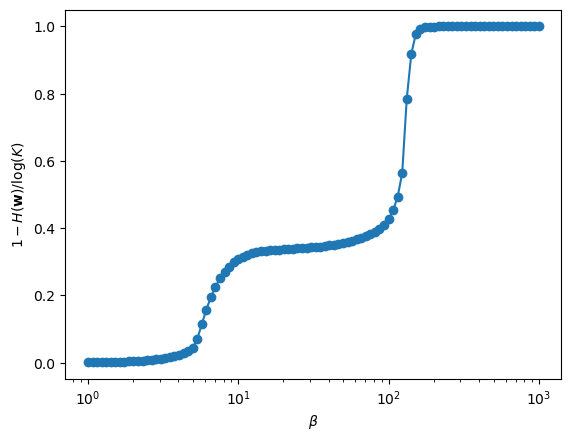

In [105]:
plt.plot(betas, 1-entropies.mean(dim=0)/log(K), marker='o')
plt.xscale('log')
plt.xlabel('$\\beta$')
plt.ylabel('$1 - H(\\mathbf{w})/\\log(K)$')
plt.show()